<a href="https://colab.research.google.com/github/anuragN2107/Covid19-Trend_Analytics-Forecasting/blob/main/Covid19_Trend_Analysis_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Given data about COVID-19 patients, write code to visualize the impact and analyze the trend of rate of infection and recovery as well as make predictions about the number of cases expected a week in future based on the current trends.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/covid_19_clean_complete.csv")

In [3]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [4]:
df.shape

(49068, 10)

In [5]:
#Rename the Columns
cols_map = {
    "Date": "date", "Province/State": "state", "Country/Region": "country",
    "Lat": "lat", "Long": "long", "Confirmed": "confirmed",
    "Deaths": "deaths", "Recovered": "recovered", "WHO Region": "who", "Active": "active"
}

df.rename(columns=cols_map, inplace=True)

In [6]:
df.head()

,state,country,lat,long,date,confirmed,deaths,recovered,active,who
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df["date"].max()


'2020-07-27'

In [8]:
#Records from the last date
df[df["date"] == df["date"].max()]


,state,country,lat,long,date,confirmed,deaths,recovered,active,who
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [9]:
top = df[df["date"] == df["date"].max()]

In [10]:
world = top.groupby("country")[["confirmed", "active", "deaths", "recovered"]].sum().reset_index()

In [11]:
world.head()

,country,confirmed,active,deaths,recovered
0,Afghanistan,36263,9796,1269,25198
1,Albania,4880,1991,144,2745
2,Algeria,27973,7973,1163,18837
3,Andorra,907,52,52,803
4,Angola,950,667,41,242


In [12]:
# Group by date and sum only the 'confirmed' column
total_cases = df.groupby("date")[["confirmed"]].sum().reset_index()

# If you want to include deaths/recovered too:
# total_cases = df.groupby("date")[["confirmed", "deaths", "recovered"]].sum().reset_index()

total_cases.head()

,date,confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [13]:
df['date'] = pd.to_datetime(df['date'])

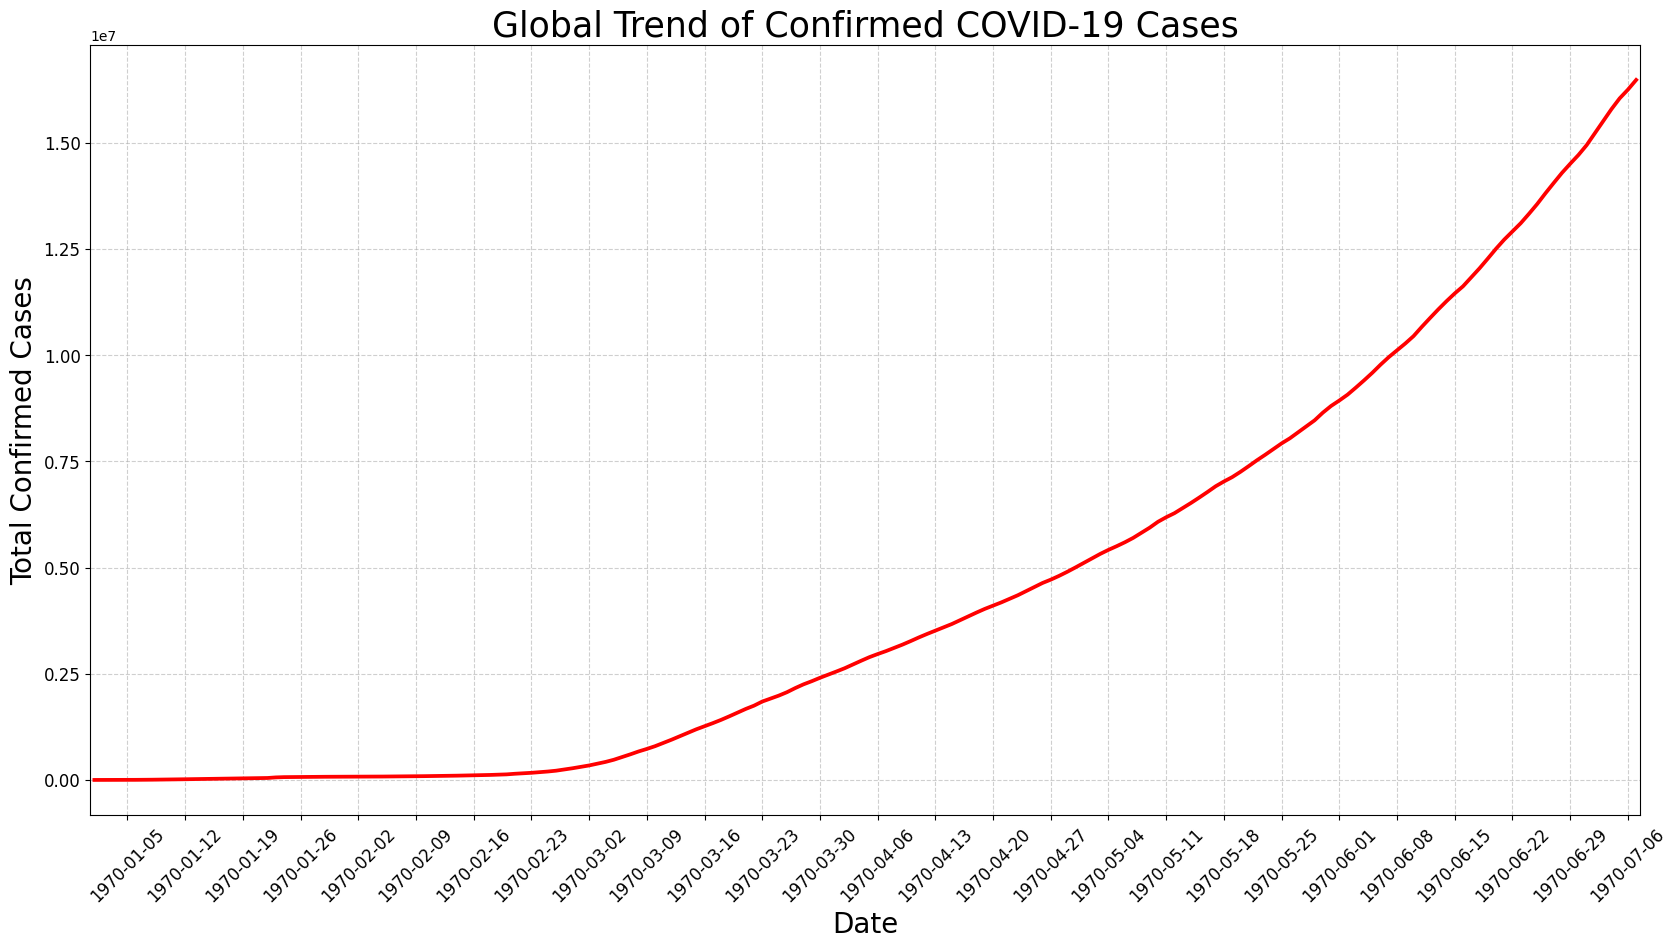

In [14]:
##Trend of Covid

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(20, 10))

ax = sns.pointplot(data=total_cases, x="date", y="confirmed", color="r", markers="")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Total Confirmed Cases", fontsize=20)
plt.title("Global Trend of Confirmed COVID-19 Cases", fontsize=25)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [15]:
# 1. Filter for the specific date first
latest_data = top[top['date'] == '2020-07-27']

# 2. Group, sum, and sort
top_actives = (latest_data.groupby("country")["active"]
               .sum()
               .sort_values(ascending=False)
               .head(20)
               .reset_index())

top_actives

,country,active
0,US,2816444
1,Brazil,508116
2,India,495499
3,United Kingdom,254427
4,Russia,201097
5,South Africa,170537
6,Colombia,117163
7,France,108928
8,Canada,107514
9,Peru,98752


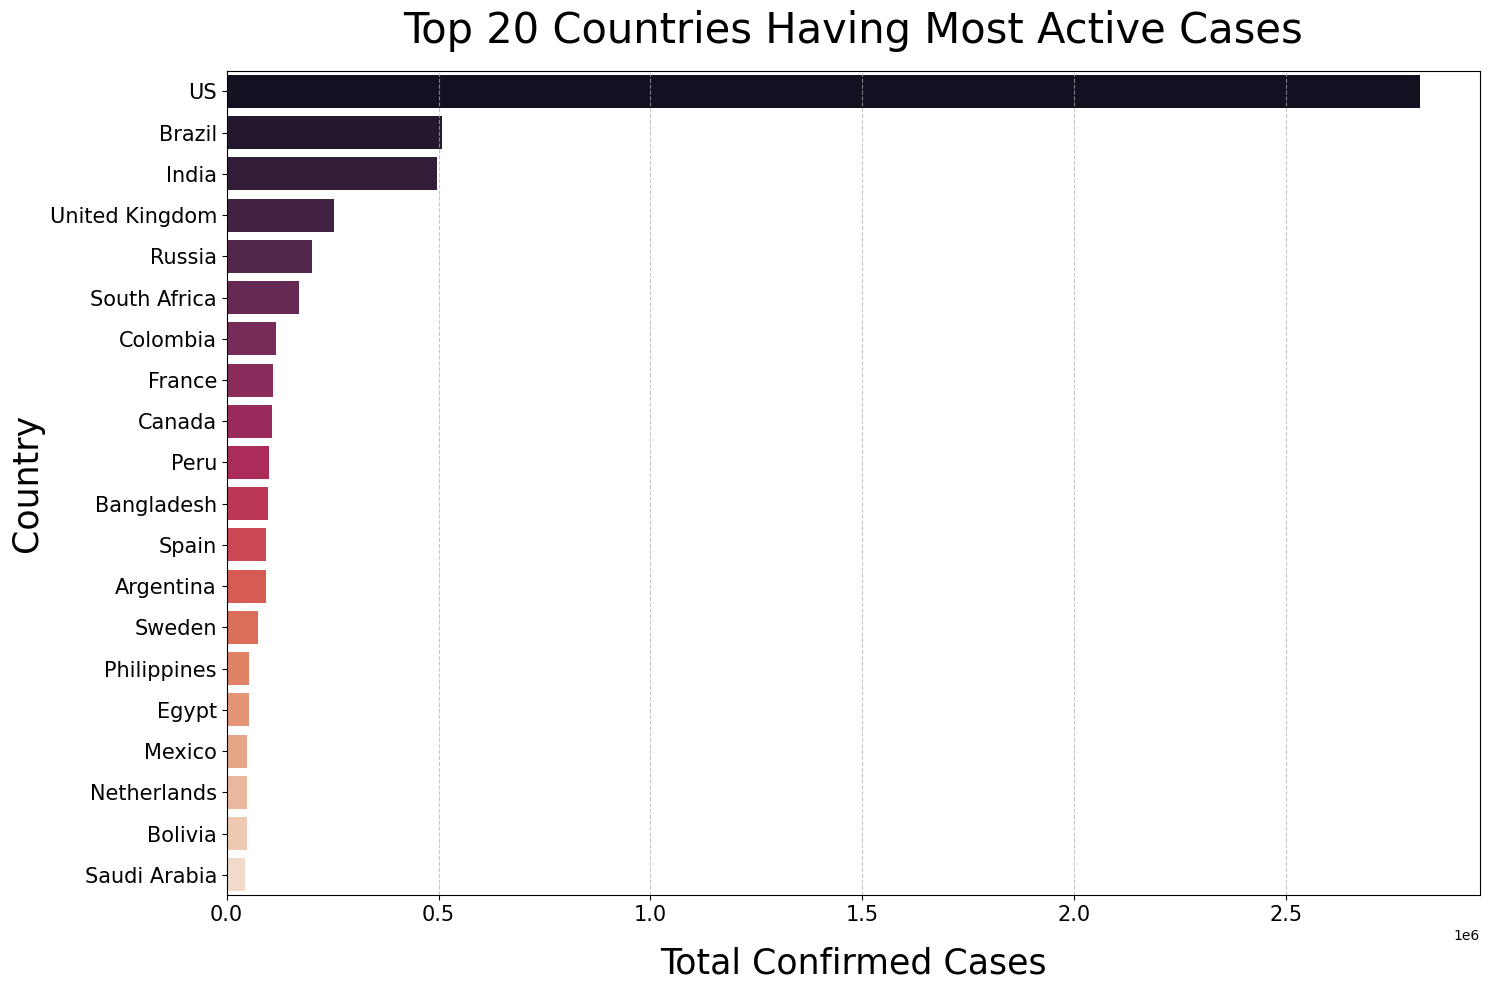

In [16]:
plt.figure(figsize=(15, 10))

ax = sns.barplot(data=top_actives, x="active", y="country", palette="rocket")

plt.title("Top 20 Countries Having Most Active Cases", fontsize=30, pad=20)
plt.xlabel("Total Confirmed Cases", fontsize=25, labelpad=15)
plt.ylabel("Country", fontsize=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
# Top 20 countries with highest number of Death cases for the latest data 27th july 2020

latest_deaths = top[top['date'] == '2020-07-27']

top_deaths = (latest_deaths.groupby("country")["deaths"]
              .sum()
              .sort_values(ascending=False)
              .head(20)
              .reset_index())

top_deaths

,country,deaths
0,US,148011
1,Brazil,87618
2,United Kingdom,45844
3,Mexico,44022
4,Italy,35112
5,India,33408
6,France,30212
7,Spain,28432
8,Peru,18418
9,Iran,15912


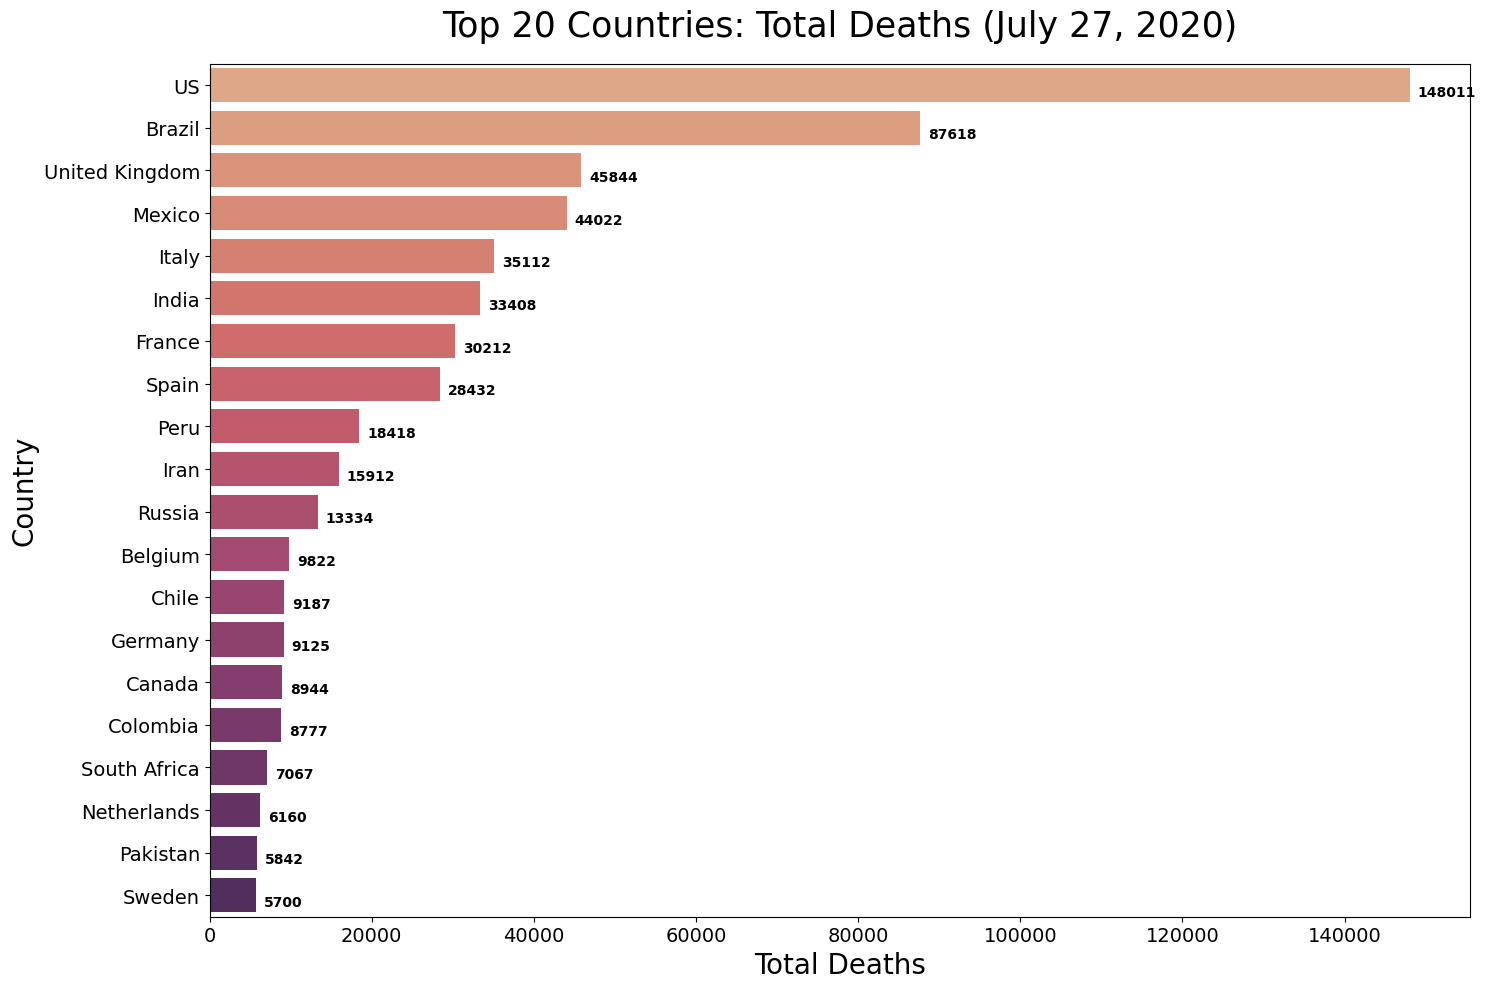

In [18]:
plt.figure(figsize=(15, 10))

ax = sns.barplot(data=top_deaths, x="deaths", y="country", palette="flare")

plt.title("Top 20 Countries: Total Deaths (July 27, 2020)", fontsize=25, pad=20)
plt.xlabel("Total Deaths", fontsize=20)
plt.ylabel("Country", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for i, v in enumerate(top_deaths.deaths):
    ax.text(v + 1000, i + .25, str(int(v)), color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Can also try with Recovered cases
# NUMBER OF PEOPLE RECOVERED
latest_recovery = top[top['date'] == '2020-07-27']
recovery = (latest_recovery.groupby("country")["recovered"]
            .sum()
            .sort_values(ascending=False)
            .head(20)
            .reset_index())

recovery

,country,recovered
0,Brazil,1846641
1,US,1325804
2,India,951166
3,Russia,602249
4,Chile,319954
5,Mexico,303810
6,South Africa,274925
7,Peru,272547
8,Iran,255144
9,Pakistan,241026


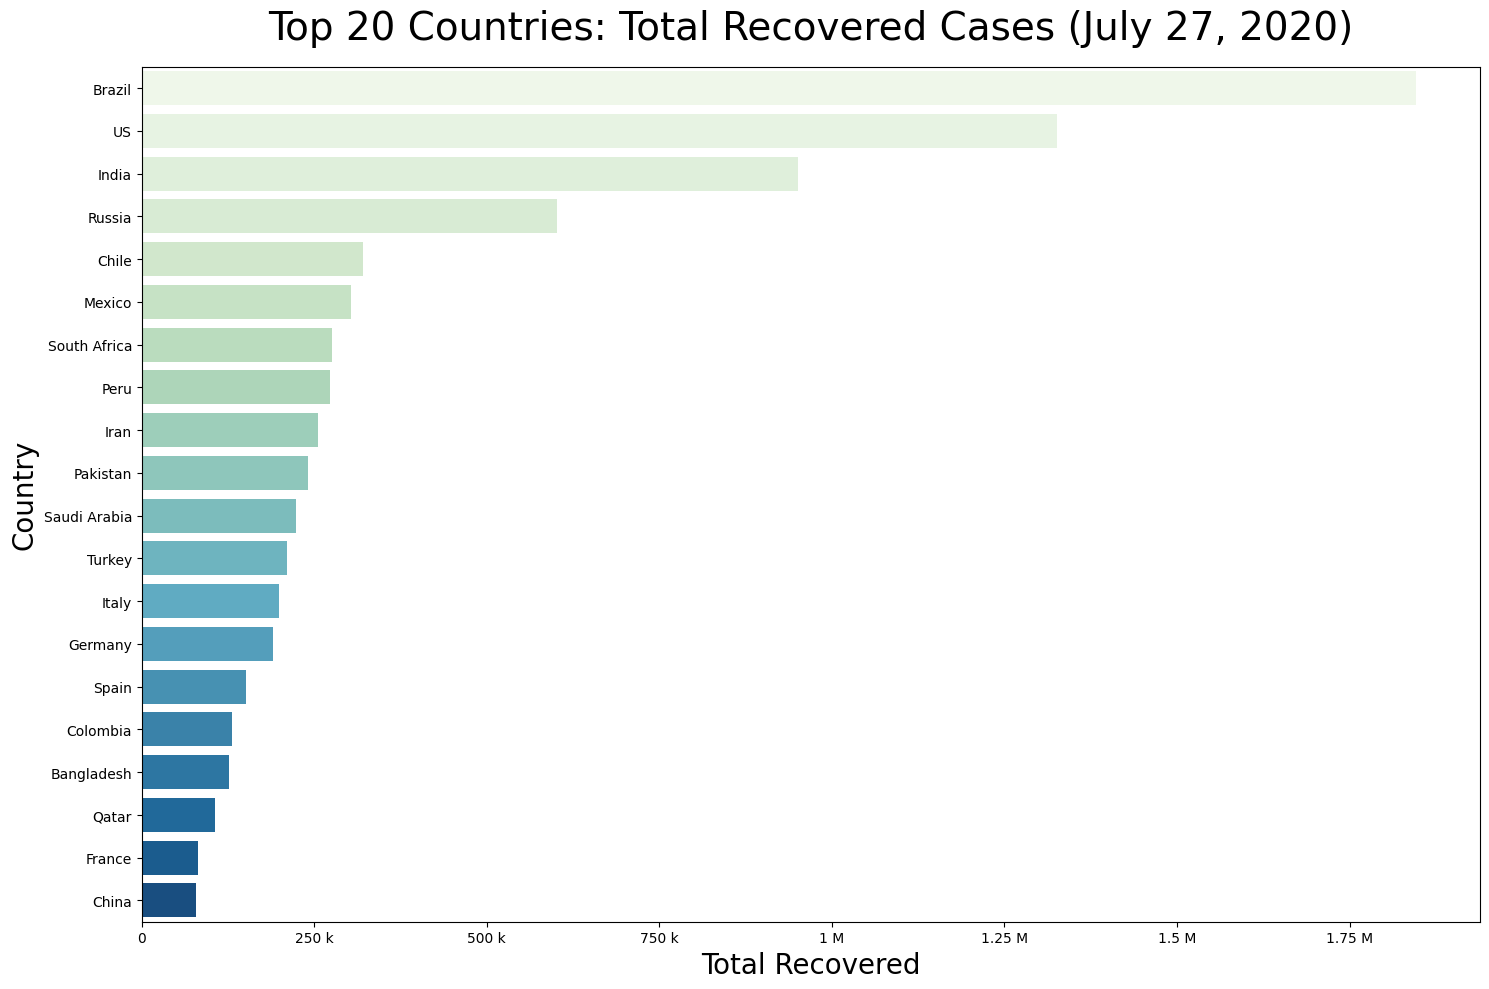

In [20]:
plt.figure(figsize=(15, 10))

ax = sns.barplot(data=recovery, x="recovered", y="country", palette="GnBu")
plt.title("Top 20 Countries: Total Recovered Cases (July 27, 2020)", fontsize=28, pad=20)
plt.xlabel("Total Recovered", fontsize=20)
plt.ylabel("Country", fontsize=20)

import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.show()

In [21]:
df["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Greenland', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala',
       'Guinea', 'Guyana', 'Haiti', 'Holy See', 'Honduras', 'Hungary',
       'Iceland', 'India', 'Ind

In [22]:
#US Data
# 1. Filter for the US
us = df[df.country == "US"]

# 2. Group by date and sum the metrics (using double brackets)
us = us.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# 3. Sort by date just to be safe (time-series must be ordered!)
us = us.sort_values("date")

us.head()

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,1,1
1,2020-01-23,0,0,1,1
2,2020-01-24,0,0,2,2
3,2020-01-25,0,0,2,2
4,2020-01-26,0,0,5,5


In [23]:
#Brazil Data
# 1. Filter for Brazil
brazil = df[df.country == "Brazil"]

# 2. Group by date and sum the key metrics
brazil = brazil.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# 3. Ensure the dates are in order for time-series analysis
brazil = brazil.sort_values("date")

brazil.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
5,2020-01-27,0,0,0,0
6,2020-01-28,0,0,0,0
7,2020-01-29,0,0,0,0
8,2020-01-30,0,0,0,0
9,2020-01-31,0,0,0,0


In [24]:
#Russsia Data
# 1. Filter for Russia
russia = df[df.country == "Russia"]

# 2. Group by date and sum the key metrics
russia = russia.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# 3. Ensure the dates are in order for time-series analysis
russia = russia.sort_values("date")

russia.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
5,2020-01-27,0,0,0,0
6,2020-01-28,0,0,0,0
7,2020-01-29,0,0,0,0
8,2020-01-30,0,0,0,0
9,2020-01-31,0,0,2,2


In [25]:
#Saudi Arabia Data
# Filter for Saudi Arabia
saudi = df[df.country == "Saudi Arabia"]

# Group by date and sum metrics
saudi = saudi.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# Sort and display
saudi = saudi.sort_values("date")
saudi.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
5,2020-01-27,0,0,0,0
6,2020-01-28,0,0,0,0
7,2020-01-29,0,0,0,0
8,2020-01-30,0,0,0,0
9,2020-01-31,0,0,0,0


In [26]:
#Peru Data
# Filter for Peru
peru = df[df.country == "Peru"]

# Group by date and sum metrics
peru = peru.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# Sort and display
peru = peru.sort_values("date")
peru.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
5,2020-01-27,0,0,0,0
6,2020-01-28,0,0,0,0
7,2020-01-29,0,0,0,0
8,2020-01-30,0,0,0,0
9,2020-01-31,0,0,0,0


In [27]:
#China Data
# 1. Filter for China
china = df[df.country == "China"]

# 2. Group by date to aggregate all provinces (Hubei, Guangdong, etc.)
china = china.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# 3. Sort by date
china = china.sort_values("date")

china.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,28,17,548,503
1,2020-01-23,30,18,643,595
2,2020-01-24,36,26,920,858
3,2020-01-25,39,42,1406,1325
4,2020-01-26,49,56,2075,1970
5,2020-01-27,58,82,2877,2737
6,2020-01-28,101,131,5509,5277
7,2020-01-29,119,133,6087,5835
8,2020-01-30,133,171,8141,7837
9,2020-01-31,211,213,9802,9378


In [28]:
#INDIA Data
# Filter for India
india = df[df.country == "India"]

# Group by date and sum metrics
india = india.groupby("date")[["recovered", "deaths", "confirmed", "active"]].sum().reset_index()

# Sort and display
india = india.sort_values("date")
india.head(50)

,date,recovered,deaths,confirmed,active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
5,2020-01-27,0,0,0,0
6,2020-01-28,0,0,0,0
7,2020-01-29,0,0,0,0
8,2020-01-30,0,0,1,1
9,2020-01-31,0,0,1,1


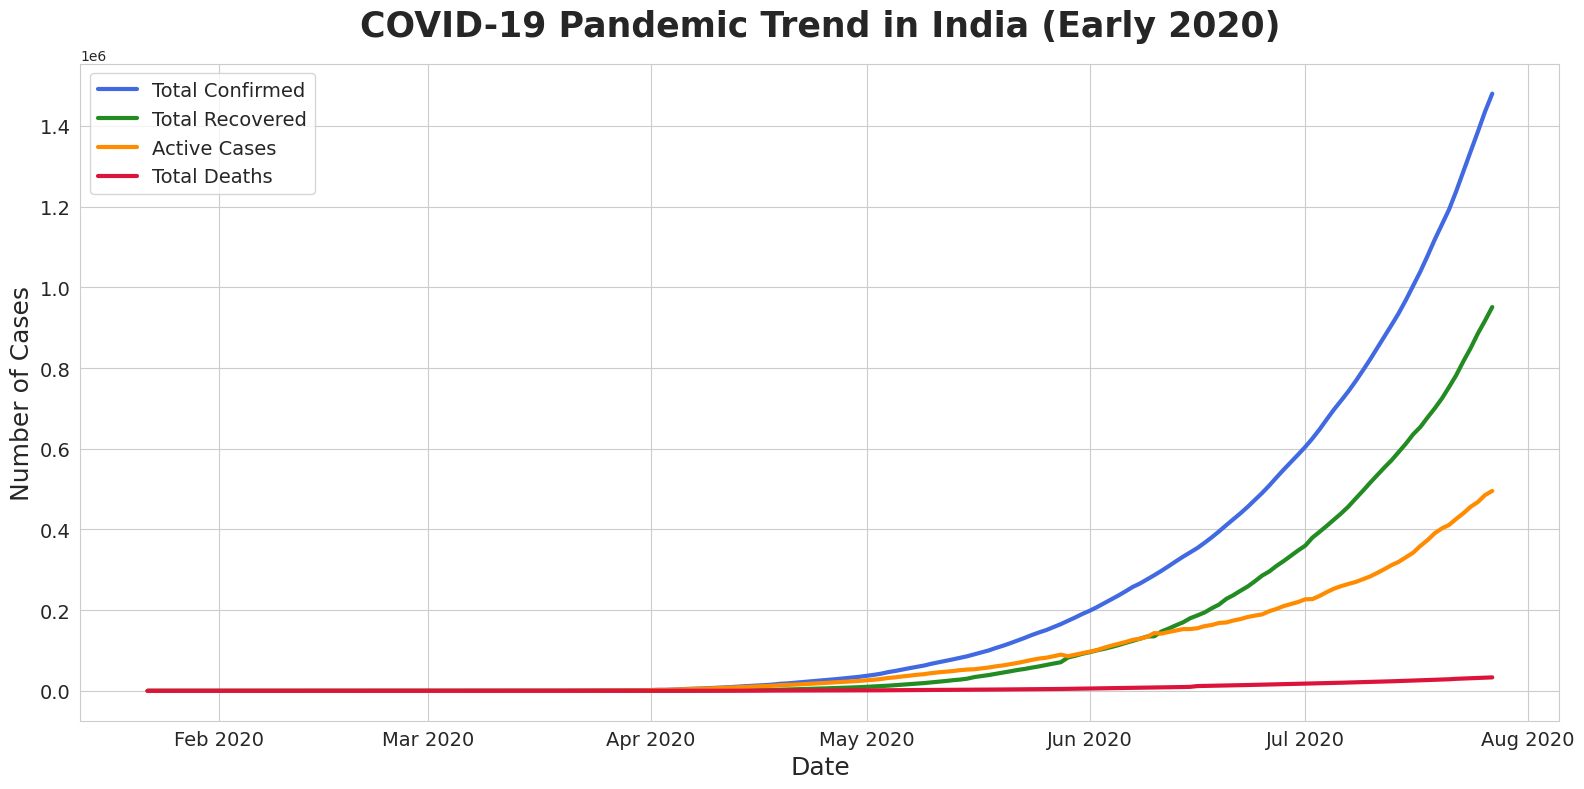

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

india = df[df.country == "India"]
india = india.groupby("date")[["confirmed", "recovered", "deaths", "active"]].sum().reset_index()
india['date'] = pd.to_datetime(india['date'])

plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

sns.lineplot(data=india, x="date", y="confirmed", label="Total Confirmed", color="royalblue", linewidth=3)
sns.lineplot(data=india, x="date", y="recovered", label="Total Recovered", color="forestgreen", linewidth=3)
sns.lineplot(data=india, x="date", y="active", label="Active Cases", color="darkorange", linewidth=3)
sns.lineplot(data=india, x="date", y="deaths", label="Total Deaths", color="crimson", linewidth=3)

plt.title("COVID-19 Pandemic Trend in India (Early 2020)", fontsize=25, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Number of Cases", fontsize=18)

# Format X-axis to show dates clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc='upper left')

# 5. Add a subtle grid and show
plt.tight_layout()
plt.show()

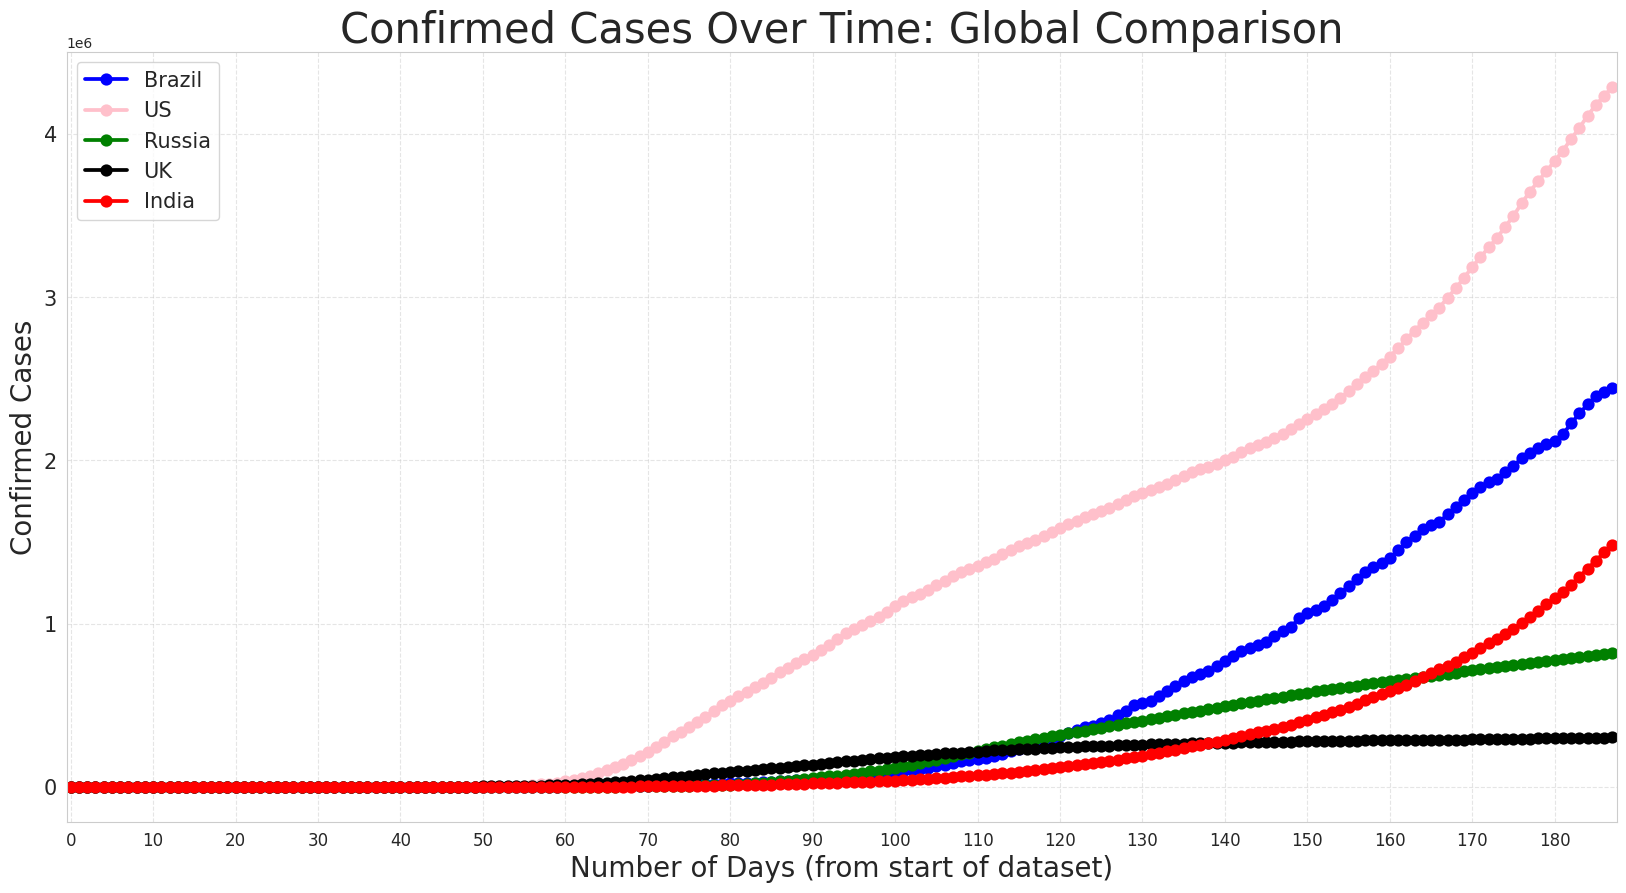

In [30]:
# confirmed cases trend in top 5 countries
def prep_data(country_name):
    temp = df[df['country'] == country_name]
    return temp.groupby('date')[['confirmed', 'deaths', 'recovered', 'active']].sum().reset_index()

brazil = prep_data("Brazil")
us = prep_data("US")
russia = prep_data("Russia")
uk = prep_data("United Kingdom")
india = prep_data("India")

plt.figure(figsize=(20, 10))

sns.pointplot(x=brazil.index, y=brazil.confirmed, color="blue", label="Brazil")
sns.pointplot(x=us.index, y=us.confirmed, color="pink", label="US")
sns.pointplot(x=russia.index, y=russia.confirmed, color="green", label="Russia")
sns.pointplot(x=uk.index, y=uk.confirmed, color="black", label="UK")
sns.pointplot(x=india.index, y=india.confirmed, color="red", label="India")

plt.xlabel('Number of Days (from start of dataset)', fontsize=20)
plt.ylabel('Confirmed Cases', fontsize=20)
plt.title('Confirmed Cases Over Time: Global Comparison', fontsize=30)

xticks = plt.gca().get_xticks()
plt.xticks(xticks[::10], fontsize=12)
plt.yticks(fontsize=15)

plt.legend(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#US having highest number of cases and rate of increasing the cases is highest

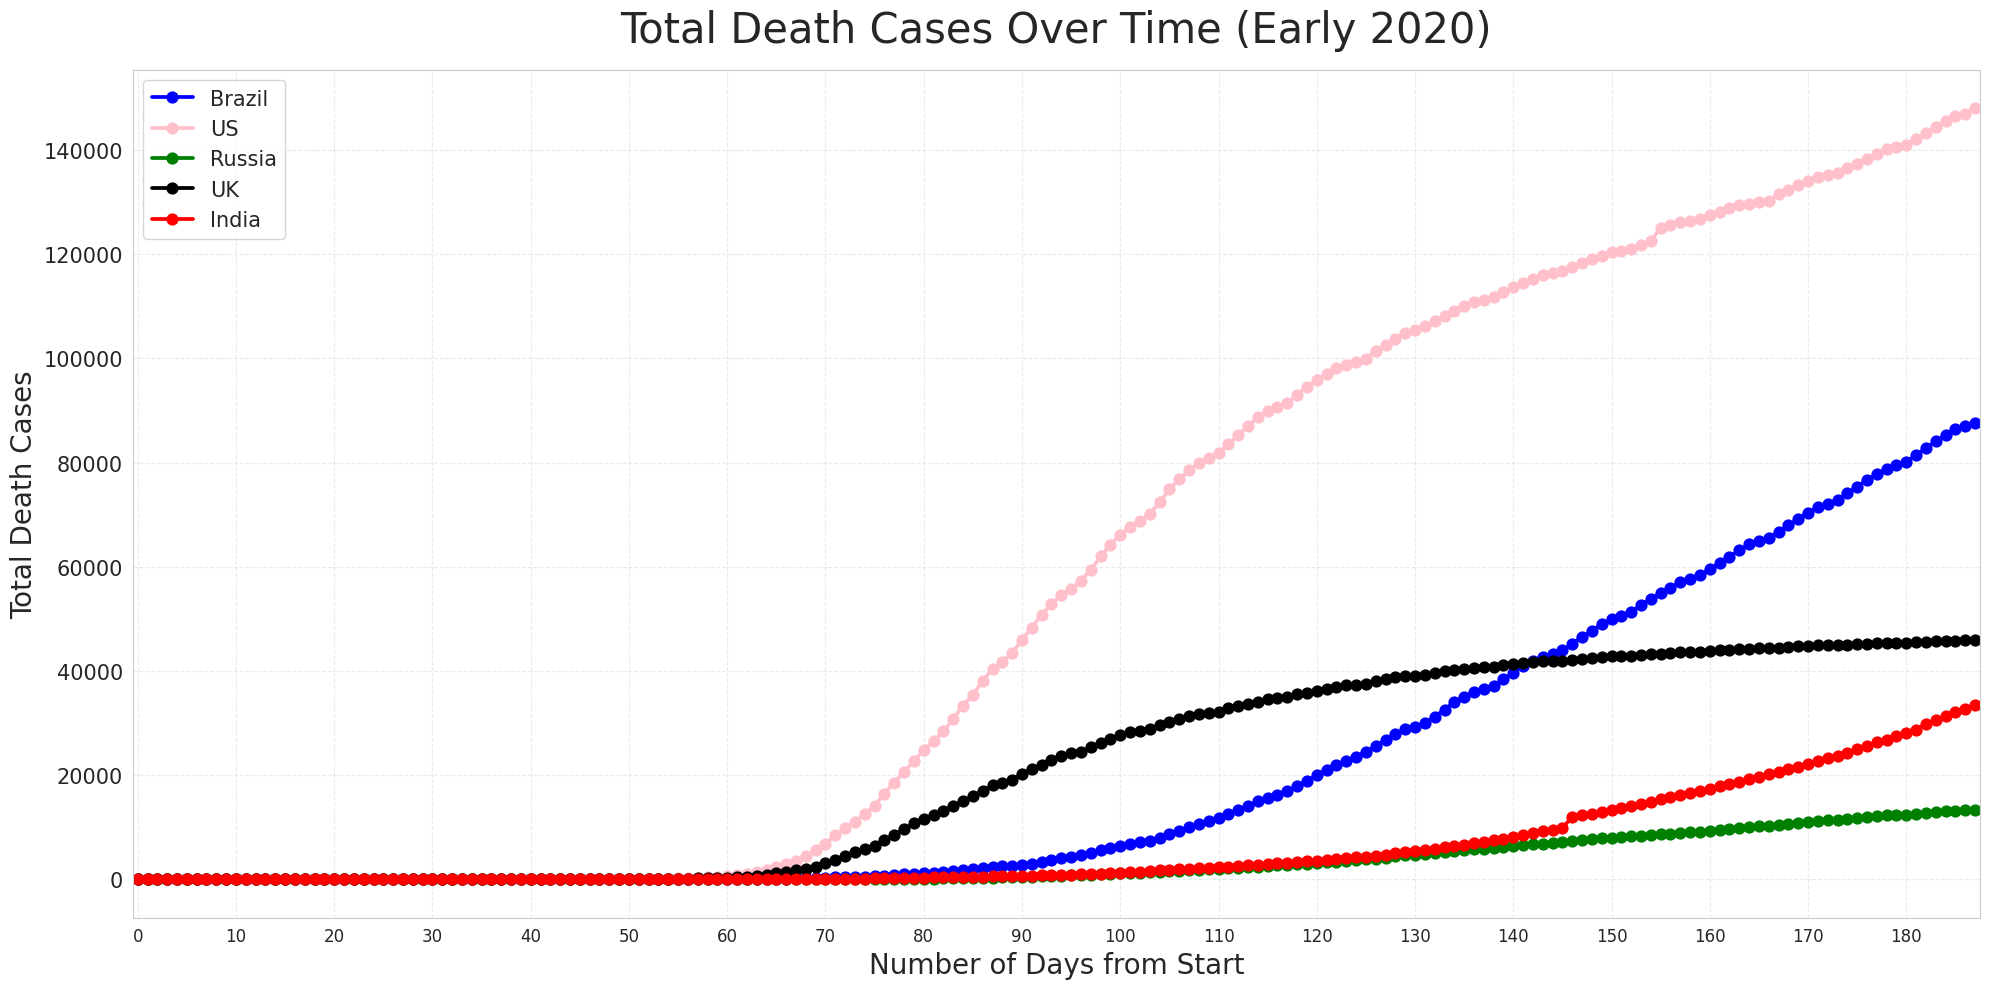

In [31]:
# Death cases trend in top 5 countries
def get_stats(country_name):
    return df[df.country == country_name].groupby('date')[['deaths']].sum().reset_index()

us = get_stats("US")
brazil = get_stats("Brazil")
india = get_stats("India")
russia = get_stats("Russia")
uk = get_stats("United Kingdom")

plt.figure(figsize=(20, 10))

sns.pointplot(x=brazil.index, y=brazil.deaths, color="blue", label="Brazil")
sns.pointplot(x=us.index, y=us.deaths, color="pink", label="US")
sns.pointplot(x=russia.index, y=russia.deaths, color="green", label="Russia")
sns.pointplot(x=uk.index, y=uk.deaths, color="black", label="UK")
sns.pointplot(x=india.index, y=india.deaths, color="red", label="India")

plt.title('Total Death Cases Over Time (Early 2020)', fontsize=30, pad=20)
plt.xlabel('Number of Days from Start', fontsize=20)
plt.ylabel('Total Death Cases', fontsize=20)

ticks = range(0, len(us), 10)
plt.xticks(ticks=ticks, labels=ticks, fontsize=12)
plt.yticks(fontsize=15)

plt.legend(fontsize=15, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

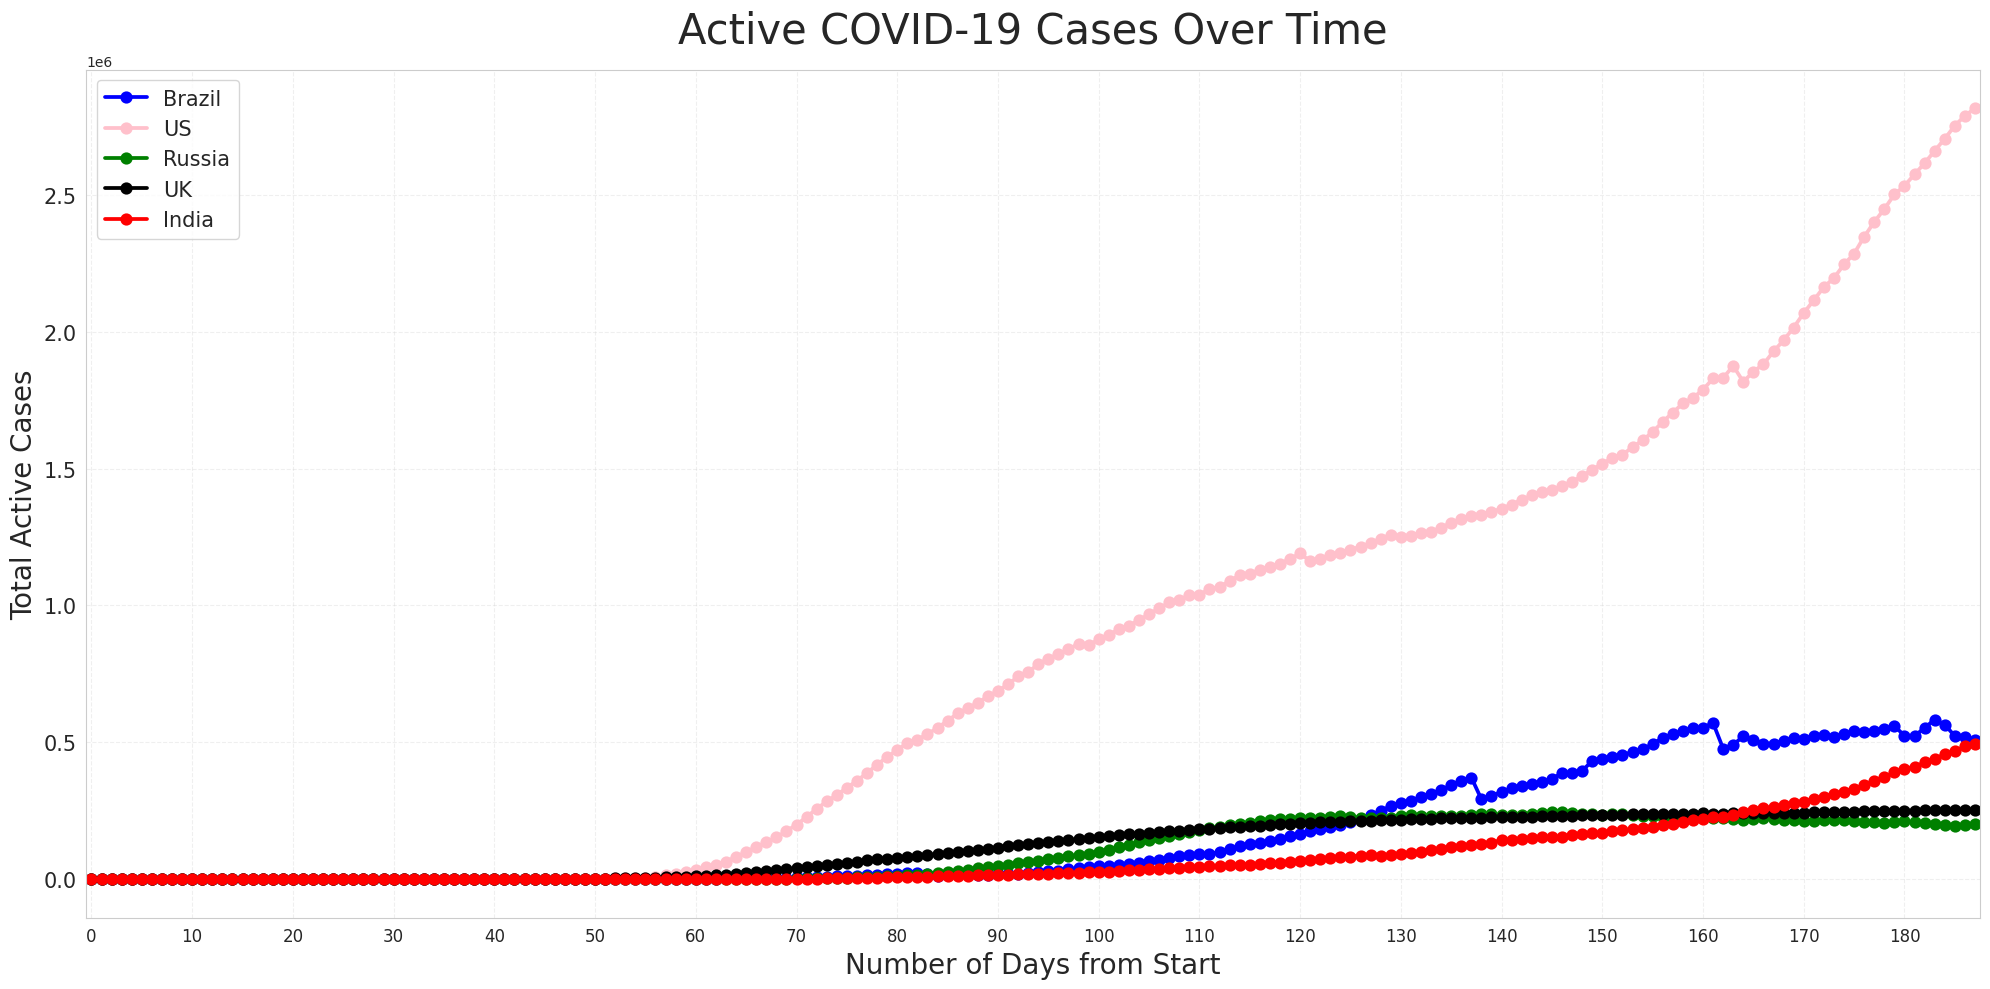

In [32]:
# active cases trend in top 5 countries
def get_active_stats(country_name):
    country_df = df[df.country == country_name]
    return country_df.groupby('date')[['active']].sum().reset_index()

us = get_active_stats("US")
brazil = get_active_stats("Brazil")
india = get_active_stats("India")
russia = get_active_stats("Russia")
uk = get_active_stats("United Kingdom")

plt.figure(figsize=(20, 10))

sns.pointplot(x=brazil.index, y=brazil.active, color="blue", label="Brazil")
sns.pointplot(x=us.index, y=us.active, color="pink", label="US")
sns.pointplot(x=russia.index, y=russia.active, color="green", label="Russia")
sns.pointplot(x=uk.index, y=uk.active, color="black", label="UK")
sns.pointplot(x=india.index, y=india.active, color="red", label="India")

plt.title('Active COVID-19 Cases Over Time', fontsize=30, pad=20)
plt.xlabel('Number of Days from Start', fontsize=20)
plt.ylabel('Total Active Cases', fontsize=20)

ticks = range(0, len(us), 10)
plt.xticks(ticks=ticks, labels=ticks, fontsize=12)
plt.yticks(fontsize=15)

plt.legend(fontsize=15, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

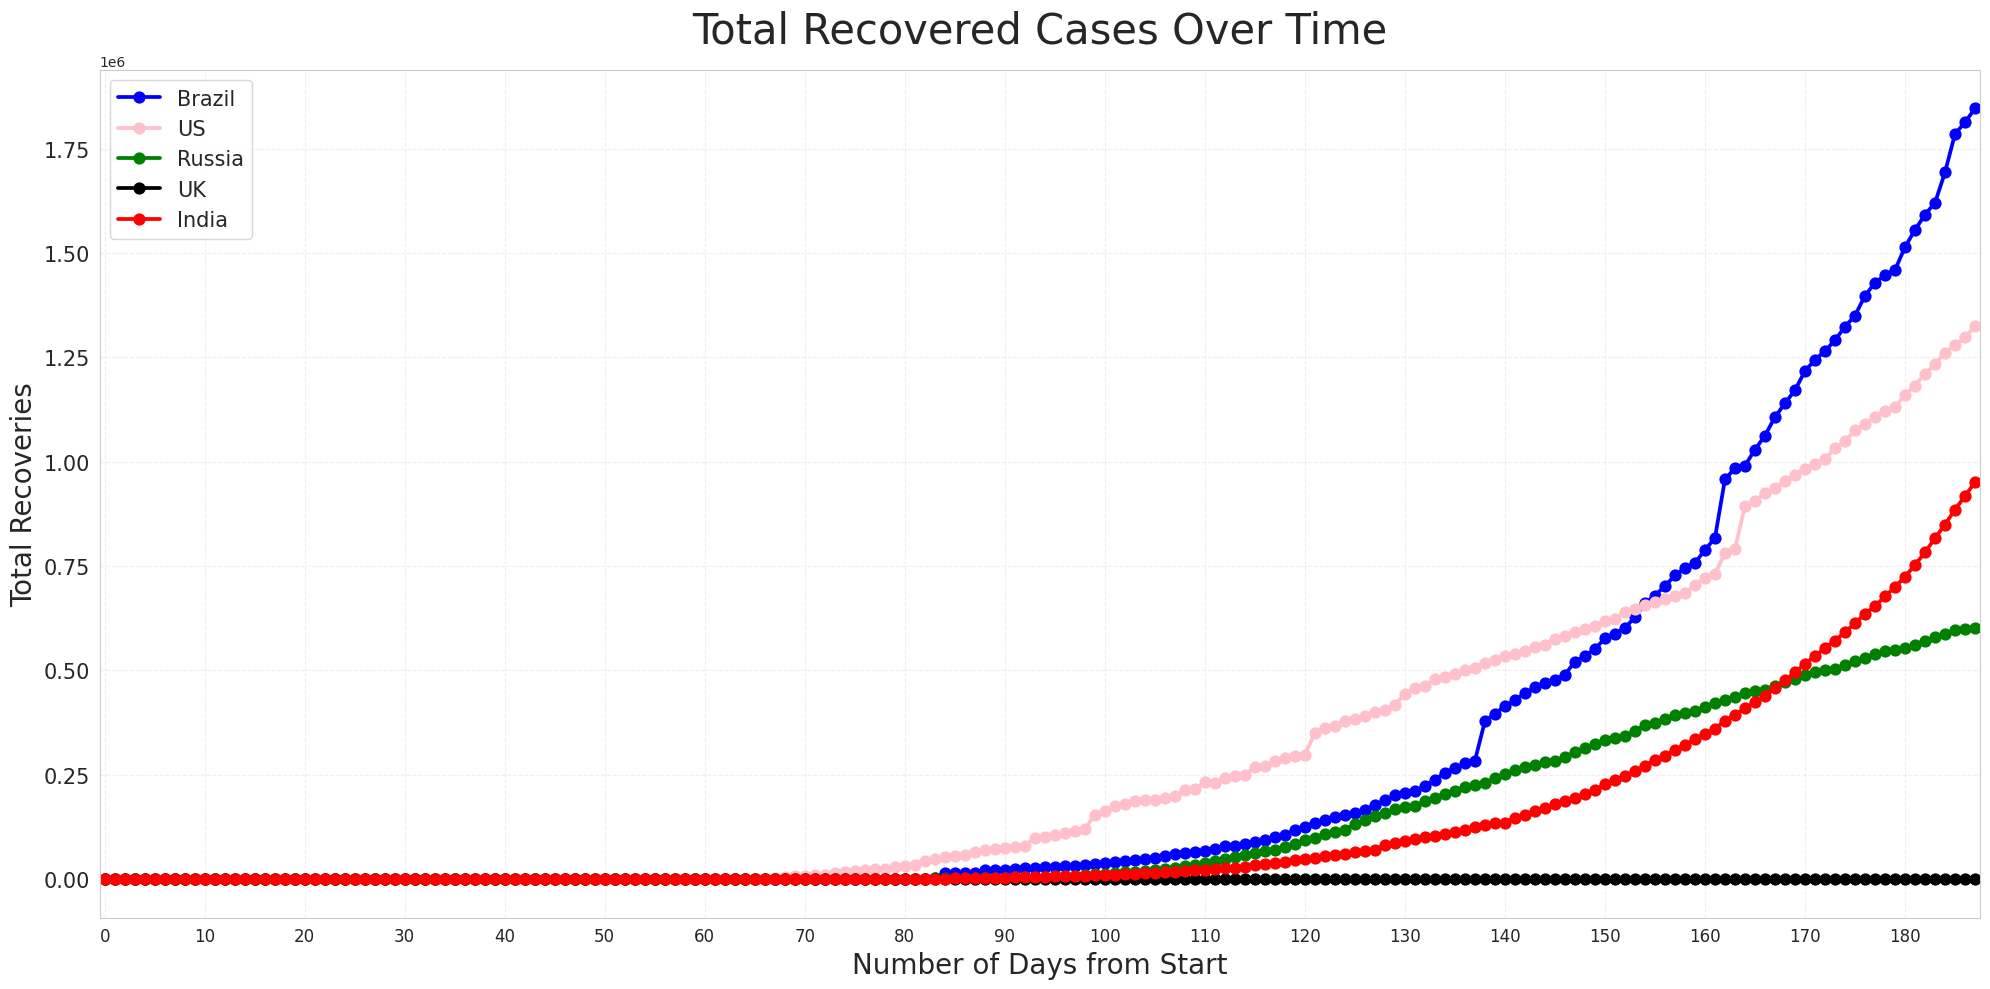

In [33]:
# recovered cases trend in top 5 countries
def get_recovery_data(country_name):
    return df[df.country == country_name].groupby('date')[['recovered']].sum().reset_index()

us = get_recovery_data("US")
brazil = get_recovery_data("Brazil")
india = get_recovery_data("India")
russia = get_recovery_data("Russia")
uk = get_recovery_data("United Kingdom")

plt.figure(figsize=(20, 10))

sns.pointplot(x=brazil.index, y=brazil.recovered, color="blue", label="Brazil")
sns.pointplot(x=us.index, y=us.recovered, color="pink", label="US")
sns.pointplot(x=russia.index, y=russia.recovered, color="green", label="Russia")
sns.pointplot(x=uk.index, y=uk.recovered, color="black", label="UK")
sns.pointplot(x=india.index, y=india.recovered, color="red", label="India")

plt.title('Total Recovered Cases Over Time', fontsize=30, pad=20)
plt.xlabel('Number of Days from Start', fontsize=20)
plt.ylabel('Total Recoveries', fontsize=20)

ticks = range(0, len(us), 10)
plt.xticks(ticks=ticks, labels=ticks, fontsize=12)
plt.yticks(fontsize=15)

plt.legend(fontsize=15, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Time Series Forecasting with Facebook Prophet

In [34]:
pip install prophet

In [35]:
from prophet import Prophet

In [36]:
data=pd.read_csv("/content/covid_19_clean_complete.csv",parse_dates=["Date"])
data

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [37]:
#To check how many total active cases are there

data["Active"].sum()

np.int64(396715350)

In [38]:
data['Confirmed'].sum()


np.int64(828508482)

In [39]:
confirmed = data.groupby("Date").sum()["Confirmed"].reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [40]:
deaths = data.groupby("Date").sum()["Deaths"].reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [41]:
recovered = data.groupby("Date").sum()["Recovered"].reset_index()
recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [42]:
confirmed.columns = ["ds", "y"]  #ds ---> date stamp, y ----> target
confirmed["ds"] = pd.to_datetime(confirmed['ds'])
confirmed.tail()

,ds,y
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


In [43]:
deaths.columns=['ds','y']
deaths['ds']=pd.to_datetime(deaths['ds'])
deaths.tail()

,ds,y
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621
187,2020-07-27,654036


In [44]:
recovered.columns=['ds','y']
recovered['ds']=pd.to_datetime(recovered['ds'])
recovered.tail()

,ds,y
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464
187,2020-07-27,9468087


In [45]:
# Filter for India
india_data = df[df.country == "India"]

india_prophet = india_data[['date', 'confirmed']].rename(columns={'date': 'ds', 'confirmed': 'y'})

india_prophet['ds'] = pd.to_datetime(india_prophet['ds'])

print(india_prophet.head())

             ds  y
129  2020-01-22  0
390  2020-01-23  0
651  2020-01-24  0
912  2020-01-25  0
1173 2020-01-26  0


In [46]:
#Training the Prophet Model
# Initialize the model
m = Prophet(interval_width=0.95, daily_seasonality=True)

# Fit the model
m.fit(india_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [47]:
#Generating 30 days forecasting
future = m.make_future_dataframe(periods=30)

forecast = m.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
213,2020-08-22,2.007121e+06,1.895984e+06,2.104835e+06
214,2020-08-23,2.034280e+06,1.935450e+06,2.131833e+06
215,2020-08-24,2.060816e+06,1.947449e+06,2.163197e+06
216,2020-08-25,2.081150e+06,1.965349e+06,2.188687e+06
217,2020-08-26,2.108129e+06,1.983815e+06,2.229610e+06


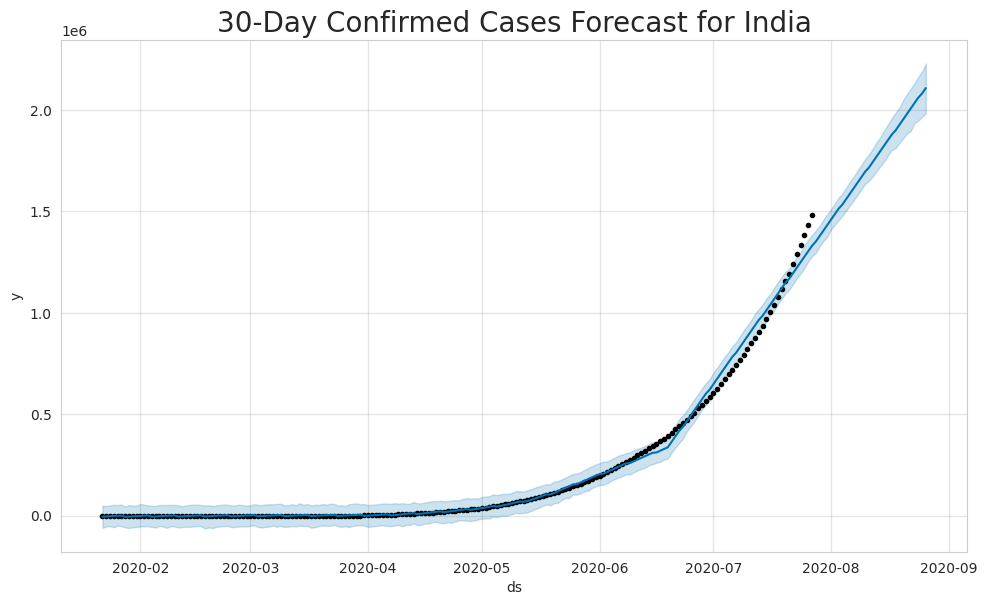

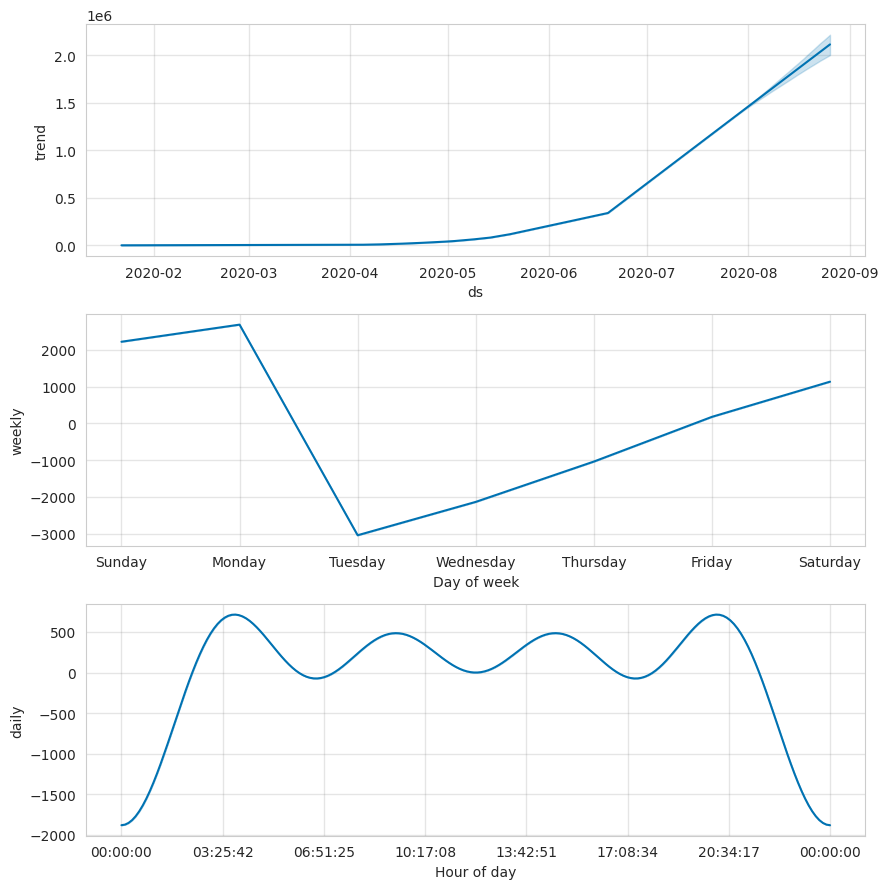

In [48]:
#Visualisation of the Forecast
fig1 = m.plot(forecast)
plt.title("30-Day Confirmed Cases Forecast for India", fontsize=20)

fig2 = m.plot_components(forecast)